#
---
---

----------------------------------------------
## 0. Environment
----------------------------------------------
PURPOSE: Setup environment and create test datasets

### 0.0 ENVIRONMENT SETUP
PURPOSE: requirements, libraries, paths

In [1]:
# INSTALL REQUIREMENTS
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
# IMPORT NECESSARY LIBRARIES
from pathlib import Path
import pandas as pd
import numpy as np
import os

import src.feature_design as fdesign 
import src.feature_builders as fbuild
import src.feature_selection as fselect

In [3]:
# ESTABLISH PATHS
BASE_DIR = Path.cwd()
print("="*100)
print("DATA PATHS AVAILABLE:\n", os.listdir(BASE_DIR))


DATA PATHS AVAILABLE:
 ['src', 'examples_notebook.ipynb', '.venv', 'archive', 'requirements.txt', 'readme.md']


### 0.1 TEST DATASET CREATION
PURPOSE: test data that's called in examples below

In [4]:
def generate_user_dataset(n_samples=1000, seed=42):
    np.random.seed(seed)
    
    # ID
    ids = np.arange(1, n_samples + 1)
    
    # Demographic features
    age = np.random.randint(18, 80, size=n_samples)
    income = np.random.normal(loc=50000, scale=15000, size=n_samples).clip(10000, 150000)
    employment_years = np.random.randint(0, 40, size=n_samples)
    
    # Behavioural features
    num_credit_cards = np.random.randint(0, 10, size=n_samples)
    avg_monthly_spend = np.random.normal(loc=1500, scale=500, size=n_samples).clip(100, 5000)
    missed_payments = np.random.poisson(lam=1.5, size=n_samples)
    
    # Categorical features (encoded as numbers for simplicity)
    education_level = np.random.choice([0, 1, 2, 3], size=n_samples)  
    # 0: high school, 1: bachelor, 2: master, 3: phd
    
    marital_status = np.random.choice([0, 1], size=n_samples)  
    # 0: single, 1: married
    
    # --- Create target with some logic (important for realism) ---
    # Higher missed payments + lower income → higher chance of target = 1
    
    risk_score = (
        0.00005 * (50000 - income) +
        0.3 * missed_payments +
        0.02 * (70 - age) +
        0.1 * (num_credit_cards > 5)
    )
    
    probability = 1 / (1 + np.exp(-risk_score))  # sigmoid
    target = np.random.binomial(1, probability)
    
    # Build DataFrame
    df = pd.DataFrame({
        "id": ids,
        "age": age,
        "income": income.astype(int),
        "employment_years": employment_years,
        "num_credit_cards": num_credit_cards,
        "avg_monthly_spend": avg_monthly_spend.astype(int),
        "missed_payments": missed_payments,
        "education_level": education_level,
        "marital_status": marital_status,
        "target": target
    })
    
    return df

test_dataset = generate_user_dataset(1000)
print("="*100)
print(test_dataset.head().to_string())

   id  age  income  employment_years  num_credit_cards  avg_monthly_spend  missed_payments  education_level  marital_status  target
0   1   56   70585                39                 3               1686                2                1               1       1
1   2   69   39833                20                 6               1735                0                2               1       0
2   3   46   67302                27                 7                821                1                3               1       0
3   4   32   44374                10                 1               1338                0                1               1       1
4   5   60   39587                33                 6               2363                0                0               1       1


----------------------------------------------
## 1: Feature design
----------------------------------------------
Goal: Transform raw data into a structure that can be used to create the feature matrix. This section covers pre-engineering cleansing of each source.

### 1.0 FEATURE REGISTRY AND SETUP

In [5]:
from src.feature_design import RegistryConfig, FeatureRegistry, FeatureSpec, Direction

# ══════════════════════════════════════════════════════════════════════════════
# GLOBAL REGISTRY INSTANCE + REGISTRATIONS
# ══════════════════════════════════════════════════════════════════════════════
# Note: All features below are given tag 'engineered' to capture engineered feature strength later

CREDIT_CONFIG = RegistryConfig(
    families = {
        "CREDIT_RISK", "REPAYMENT", "INCOME_BURDEN",
        "BEHAVIOURAL", "DEMOGRAPHIC",
    },
    sources = {
        "TEST_DATASET", "DERVIED"
    },
)

REGISTRY = FeatureRegistry(config=CREDIT_CONFIG)

REGISTRY.register_many([

    # ══════════════════════════════════════════════════════════════════════
    # INCOME / AFFORDABILITY
    # ══════════════════════════════════════════════════════════════════════

    FeatureSpec('SPEND_INCOME_RATIO', "INCOME_BURDEN", "TEST_DATASET",
                'Monthly spend as a fraction of monthly income — proxy for affordability pressure',
                formula='avg_monthly_spend / (income / 12)',
                compute=lambda df: df['avg_monthly_spend'] / (df['income'] / 12).replace(0, np.nan),
                actionable=True, direction=Direction.POSITIVE,
                tags=['affordability', 'engineered']),

    FeatureSpec('CARDS_PER_INCOME', "INCOME_BURDEN", "TEST_DATASET",
                'Number of credit cards relative to income — proxy for credit exposure',
                formula='num_credit_cards / income',
                compute=lambda df: df['num_credit_cards'] / df['income'].replace(0, np.nan),
                actionable=True, direction=Direction.POSITIVE,
                tags=['credit_exposure', 'engineered']),

    FeatureSpec('SPEND_PER_CARD', "INCOME_BURDEN", "TEST_DATASET",
                'Average spend per credit card — intensity of usage',
                formula='avg_monthly_spend / num_credit_cards',
                compute=lambda df: df['avg_monthly_spend'] / df['num_credit_cards'].replace(0, np.nan),
                actionable=True, direction=Direction.NONLINEAR,
                tags=['utilisation_proxy', 'engineered']),

    # ══════════════════════════════════════════════════════════════════════
    # CREDIT RISK / BEHAVIOUR
    # ══════════════════════════════════════════════════════════════════════

    FeatureSpec('MISSED_PAYMENT_FLAG', "CREDIT_RISK", "TEST_DATASET",
                'Flag indicating whether the user has any missed payments',
                formula='missed_payments > 0',
                compute=lambda df: (df['missed_payments'] > 0).astype(int),
                actionable=True, direction=Direction.POSITIVE,
                tags=['delinquency', 'engineered']),

    FeatureSpec('HEAVY_DELINQUENCY_FLAG', "CREDIT_RISK", "TEST_DATASET",
                'Flag for high number of missed payments (>=3)',
                formula='missed_payments >= 3',
                compute=lambda df: (df['missed_payments'] >= 3).astype(int),
                actionable=True, direction=Direction.POSITIVE,
                tags=['delinquency', 'engineered']),

    FeatureSpec('CARDS_GT_5_FLAG', "CREDIT_RISK", "TEST_DATASET",
                'Flag for users with many credit cards (>5)',
                formula='num_credit_cards > 5',
                compute=lambda df: (df['num_credit_cards'] > 5).astype(int),
                actionable=True, direction=Direction.POSITIVE,
                tags=['credit_exposure', 'engineered']),

    # ══════════════════════════════════════════════════════════════════════
    # "DEMOGRAPHIC" / STABILITY
    # ══════════════════════════════════════════════════════════════════════

    FeatureSpec('EMPLOYMENT_TO_AGE', "DEMOGRAPHIC", "TEST_DATASET",
                'Proportion of life spent employed — stability proxy',
                formula='employment_years / age',
                compute=lambda df: df['employment_years'] / df['age'].replace(0, np.nan),
                actionable=True, direction=Direction.NEGATIVE,
                tags=['stability', 'engineered']),

    FeatureSpec('YOUNG_FLAG', "DEMOGRAPHIC", "TEST_DATASET",
                'Flag for young individuals (<25)',
                formula='age < 25',
                compute=lambda df: (df['age'] < 25).astype(int),
                actionable=False, direction=Direction.POSITIVE,
                tags=['"DEMOGRAPHIC"', 'engineered']),

    FeatureSpec('NEAR_RETIREMENT_FLAG', "DEMOGRAPHIC", "TEST_DATASET",
                'Flag for older individuals (>60)',
                formula='age > 60',
                compute=lambda df: (df['age'] > 60).astype(int),
                actionable=False, direction=Direction.NONLINEAR,
                tags=['"DEMOGRAPHIC"', 'engineered']),

    # ══════════════════════════════════════════════════════════════════════
    # EDUCATION / SOCIO-ECONOMIC
    # ══════════════════════════════════════════════════════════════════════

    FeatureSpec('HIGH_EDUCATION_FLAG', "DEMOGRAPHIC", "TEST_DATASET",
                'Flag for higher education (Masters or PhD)',
                formula='education_level >= 2',
                compute=lambda df: (df['education_level'] >= 2).astype(int),
                actionable=False, direction=Direction.NEGATIVE,
                tags=['education', 'engineered']),

    FeatureSpec('MARRIED_FLAG', "DEMOGRAPHIC", "TEST_DATASET",
                'Binary marital status feature',
                formula='marital_status == 1',
                compute=lambda df: (df['marital_status'] == 1).astype(int),
                actionable=False, direction=Direction.NONLINEAR,
                tags=['"DEMOGRAPHIC"', 'engineered']),

    # ══════════════════════════════════════════════════════════════════════
    # INTERACTION FEATURES 
    # ══════════════════════════════════════════════════════════════════════

    FeatureSpec('RISK_INTERACTION', "CREDIT_RISK", "TEST_DATASET",
                'Interaction between missed payments and income — amplifies risk signal',
                formula='missed_payments * (1 / income)',
                compute=lambda df: df['missed_payments'] / df['income'].replace(0, np.nan),
                actionable=False, direction=Direction.POSITIVE,
                tags=['interaction', 'engineered']),

    FeatureSpec('SPEND_RISK_SCORE', "CREDIT_RISK", "TEST_DATASET",
                'Combined behavioural risk proxy using spend and missed payments',
                formula='avg_monthly_spend * missed_payments',
                compute=lambda df: df['avg_monthly_spend'] * df['missed_payments'],
                actionable=False, direction=Direction.POSITIVE,
                tags=['interaction', 'engineered']),
])

print("="*100,)
for spec in REGISTRY.by_tag(tag='engineered'):
    print(f"{spec.name:<25}     {spec.description}")

SPEND_INCOME_RATIO            Monthly spend as a fraction of monthly income — proxy for affordability pressure
CARDS_PER_INCOME              Number of credit cards relative to income — proxy for credit exposure
SPEND_PER_CARD                Average spend per credit card — intensity of usage
MISSED_PAYMENT_FLAG           Flag indicating whether the user has any missed payments
HEAVY_DELINQUENCY_FLAG        Flag for high number of missed payments (>=3)
CARDS_GT_5_FLAG               Flag for users with many credit cards (>5)
EMPLOYMENT_TO_AGE             Proportion of life spent employed — stability proxy
YOUNG_FLAG                    Flag for young individuals (<25)
NEAR_RETIREMENT_FLAG          Flag for older individuals (>60)
HIGH_EDUCATION_FLAG           Flag for higher education (Masters or PhD)
MARRIED_FLAG                  Binary marital status feature
RISK_INTERACTION              Interaction between missed payments and income — amplifies risk signal
SPEND_RISK_SCORE              

----------------------------------------------
## 2: Feature building
----------------------------------------------
Goal: Transform cleansed data into a model-ready feature matrix. This section covers construction of features from each source, followed by the combined modelling table and feature selection.

In [6]:
from src.feature_builders import sanitise_columns, build_features, downcast_dtypes

test_dataset_sanitised = sanitise_columns(test_dataset)

test_dataset_features = build_features(
    df = test_dataset_sanitised,
    registry = REGISTRY,
    source = "TEST_DATASET",
    id_col = None,
    sampling_ids = None,
    sentinel_cols = None,
    sentinel_value = 365243,
    null_thresh = 0.50,
    fill_nulls = False,
    encode = True,
    max_binary_card = 2,
    dummy_na = False,
    verbose = True
)
test_dataset_features = downcast_dtypes(test_dataset_features) 

print("="*100)
print("HEAD: \n", test_dataset_features.head().to_string())

print("="*100)
print("COLUMNS:")
for col in test_dataset_features.columns: print(col) 

  build_from_registry [TEST_DATASET]: +13 features
  build_features output shape : (1000, 23)
  Nulls remaining             : 112
DOWNCAST DTYPES
  Before : 0.2 MB
  After  : 0.0 MB
  Saving : 76.0%
HEAD: 
    id  age  income  employment_years  num_credit_cards  avg_monthly_spend  missed_payments  education_level  marital_status  target  SPEND_INCOME_RATIO  CARDS_PER_INCOME  SPEND_PER_CARD  MISSED_PAYMENT_FLAG  HEAVY_DELINQUENCY_FLAG  CARDS_GT_5_FLAG  EMPLOYMENT_TO_AGE  YOUNG_FLAG  NEAR_RETIREMENT_FLAG  HIGH_EDUCATION_FLAG  MARRIED_FLAG  RISK_INTERACTION  SPEND_RISK_SCORE
0   1   56   70585                39                 3               1686                2                1               1       1            0.286633          0.000043      562.000000                    1                       0                0           0.696429           0                     0                    0             1          0.000028              3372
1   2   69   39833                20             

In [7]:
# ── BULK REGISTER ASSEMBLED COLUMNS ───────────────────────────────────────────
# The build functions created and prefixed hundreds of aggregated columns
# (BUREAU_*, PREV_*, CC_*, etc.) that aren't individually registered yet.
# bulk_register picks them all up using the prefix map.
# Columns already registered explicitly (e.g. ANNUITY_INCOME_RATIO) are
# skipped — bulk_register never overwrites an existing entry.

# prefix_map format:
#     { 'PREFIX_': (FeatureFamily, FeatureSource, description, actionable, direction) }
from src.feature_design import Direction

PREFIX_MAP = {
    # ── APPLICATION — raw columns not covered by explicit registrations ────────
    'EXT_SOURCE':                    ("CREDIT_RISK",   "TEST_DATASET",  'External credit score signal',                            False, Direction.NONLINEAR),
    'AMT_':                          ("INCOME_BURDEN", "TEST_DATASET",  'Financial amount from application',                       True,  Direction.NONLINEAR),
    'DAYS_':                         ("DEMOGRAPHIC",   "TEST_DATASET",  'Days-based timing feature from application',              False, Direction.NONLINEAR),
    'FLAG_':                         ("DEMOGRAPHIC",   "TEST_DATASET",  'Binary flag from application',                            False, Direction.NONLINEAR),
    'CNT_':                          ("DEMOGRAPHIC",   "TEST_DATASET",  'Count feature from application',                          False, Direction.NONLINEAR),
    'REGION_':                       ("DEMOGRAPHIC",   "TEST_DATASET",  'Regional indicator from application',                     False, Direction.NONLINEAR),
    'LIVE_':                         ("DEMOGRAPHIC",   "TEST_DATASET",  'Residence indicator from application',                    False, Direction.NONLINEAR),
    'REG_':                          ("DEMOGRAPHIC",   "TEST_DATASET",  'Registration indicator from application',                 False, Direction.NONLINEAR),
    'HOUR_':                         ("DEMOGRAPHIC",   "TEST_DATASET",  'Hour of application process start',                       False, Direction.NONLINEAR),
    'WEEKDAY_':                      ("DEMOGRAPHIC",   "TEST_DATASET",  'Day of week of application',                              False, Direction.NONLINEAR),
    'OCCUPATION_TYPE_':              ("DEMOGRAPHIC",   "TEST_DATASET",  'Occupation type indicator',                               False, Direction.NONLINEAR),
    'ORGANIZATION_TYPE_':            ("DEMOGRAPHIC",   "TEST_DATASET",  'Organisation type indicator',                             False, Direction.NONLINEAR),
    'NAME_':                         ("DEMOGRAPHIC",   "TEST_DATASET",  'Categorical indicator from application',                  False, Direction.NONLINEAR),
    'CODE_':                         ("DEMOGRAPHIC",   "TEST_DATASET",  'Coded categorical from application',                      False, Direction.NONLINEAR),
    'YEARS_':                        ("DEMOGRAPHIC",   "TEST_DATASET",  'Years-based feature from application',                    False, Direction.NONLINEAR),

    # ── UNUSUAL PREFIXES ─────────────────────────────────────────────────────
    'TOTALAREA_':        ("DEMOGRAPHIC", "TEST_DATASET", 'Total area mode from application',          False, Direction.NONLINEAR),
    'OBS_':              ("DEMOGRAPHIC", "TEST_DATASET", 'Social circle observation count',           False, Direction.NONLINEAR),
    'DEF_':              ("DEMOGRAPHIC", "TEST_DATASET", 'Social circle default count',               False, Direction.POSITIVE),
    'FONDKAPREMONT_':    ("DEMOGRAPHIC", "TEST_DATASET", 'Building repair fund type indicator',       False, Direction.NONLINEAR),
    'HOUSETYPE_':        ("DEMOGRAPHIC", "TEST_DATASET", 'House type indicator',                      False, Direction.NONLINEAR),
    'WALLSMATERIAL_':    ("DEMOGRAPHIC", "TEST_DATASET", 'Wall material indicator',                   False, Direction.NONLINEAR),
    'EMERGENCYSTATE_':   ("DEMOGRAPHIC", "TEST_DATASET", 'Emergency state indicator',                 False, Direction.NONLINEAR),
    'FLOORSMAX_':        ("DEMOGRAPHIC", "TEST_DATASET", 'Maximum number of floors in building',      False, Direction.NONLINEAR),
}

all_cols = [c for c in test_dataset_features.columns if c != 'target']
REGISTRY.bulk_register(all_cols, PREFIX_MAP) 
REGISTRY.summary()

bulk_register: 13 columns already explicitly registered — skipped (correct)
bulk_register: 9 columns matched no prefix and are unregistered:
['id', 'age', 'income', 'employment_years', 'num_credit_cards', 'avg_monthly_spend', 'missed_payments', 'education_level', 'marital_status']
Registry summary — 13 features
  By source:
    TEST_DATASET                      13
  By family:
    CREDIT_RISK                        5
    DEMOGRAPHIC                        5
    INCOME_BURDEN                      3
  Computable (have compute fn): 13
  Actionable:                   7
  Tagged engineered:            13


----------------------------------------------
## 3: Feature selection
----------------------------------------------
Goal: Build, evaluate, and interpret a defensible delinquency prediction model. Three algorithms are compared - Logistic Regression (interpretable baseline), Random Forest, and LightGBM. Champion selected by PR-AUC on the held-out test set.

  Running correlation filter...
  Correlation pass: 4 features tagged CORRELATED
  Running quick LGB importance pass...
  LGB pass: 18 in top 100, 2 zero importance, 0 dropped (includes zero)


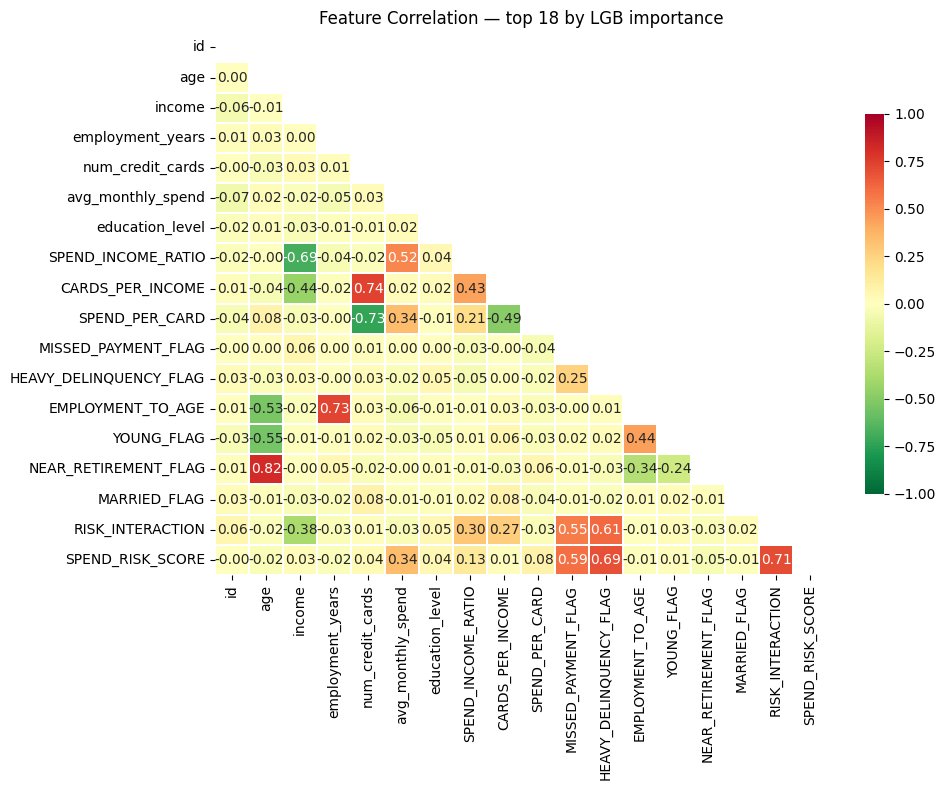

  Registry tags updated for 13 features
  Audited: 22  |  Flagged: 22  |  Binary: 8  |  Continuous: 14
  CONTINUOUS FEATURES — top 14 by effect size
           feature  null_pct  zero_pct          std  skew  target_corr  p_value  effect_size                             flags
            income       0.0       0.0 15906.745300 -0.03      -0.3013   0.0000       0.6441          EXTREME_RANGE, LGB_TOP_N
  RISK_INTERACTION       0.0      21.9     0.000000  1.81       0.2057   0.0000       0.4396          NEAR_CONSTANT, LGB_TOP_N
SPEND_INCOME_RATIO       0.0       0.0     0.247000  2.60       0.1698   0.0000       0.3629                         LGB_TOP_N
               age       0.0       0.0    18.114300 -0.07      -0.1420   0.0000       0.3035                         LGB_TOP_N
   missed_payments       0.0      21.9     1.204700  0.78       0.1231   0.0001       0.2631                        CORRELATED
  CARDS_PER_INCOME       0.0      11.2     0.000100  2.39       0.1113   0.0004       0.2

In [8]:
from src.feature_selection import feature_audit, display_audit

audit = feature_audit(
    df                   = test_dataset_features.drop(columns=['target']),
    target               = test_dataset_features['target'],
    registry             = REGISTRY,
    tag_registry         = True,
    run_correlation      = True,
    correlation_threshold= 0.85,
    run_lgb              = True,
    lgb_top_n            = 100, 
    # Note after feature selection this doesn't guarantee 100 features, as they could be removed due to other factors
)

display_audit(audit, top_n=30)
tag_list =  ['high_null',
            'near_constant',
            'low_prevalence',
            'high_prevalence',
            'correlated',
            'zero_lgb_importance',
            'dropped_lgb_top_n',
            ]

In [9]:
from src.feature_selection import feature_select
test_dataset_selected = test_dataset_features.set_index('id')

selected_features = feature_select(
    test_dataset_selected,
    target_var = 'target',
    registry = REGISTRY,
    DROP_TAGS = [
                'high_null',
                # 'not_sig',
                'near_constant',
                'low_prevalence',
                'high_prevalence',
                # 'high_skew',
                'extreme_range',
                'correlated',
                # 'zero_lgb_importance',
                'dropped_lgb_top_n',
                ]
)

print("="*100)
print('SELECTED FEATURES:\n', selected_features)

test_dataset_selected = test_dataset_selected[selected_features + ['target']]
print("="*100)
print("SELECTED FEATURES + TARGET:\n", test_dataset_selected.columns.to_list())

FEATURE SELECTION
  Starting: 21 features
  high_null                      dropped     0  →  kept    21
  near_constant                  dropped     2  →  kept    19
  low_prevalence                 dropped     0  →  kept    19
  high_prevalence                dropped     0  →  kept    19
  extreme_range                  dropped     2  →  kept    17
  correlated                     dropped     2  →  kept    15
  dropped_lgb_top_n              dropped     0  →  kept    15
SELECTED FEATURES:
 ['age', 'income', 'employment_years', 'num_credit_cards', 'avg_monthly_spend', 'missed_payments', 'education_level', 'marital_status', 'SPEND_INCOME_RATIO', 'MISSED_PAYMENT_FLAG', 'HEAVY_DELINQUENCY_FLAG', 'EMPLOYMENT_TO_AGE', 'YOUNG_FLAG', 'NEAR_RETIREMENT_FLAG', 'MARRIED_FLAG']
SELECTED FEATURES + TARGET:
 ['age', 'income', 'employment_years', 'num_credit_cards', 'avg_monthly_spend', 'missed_payments', 'education_level', 'marital_status', 'SPEND_INCOME_RATIO', 'MISSED_PAYMENT_FLAG', 'HEAVY_DELINQU

In [10]:
# View all computable features and their aggregated descendants
REGISTRY.inspect(
    search_pattern  = '.',        # matches everything
    match_columns   = list(test_dataset_features.columns),
    show_candidates = True,
    filter_tags     = 'engineered'
)

  Registry inspect — 13 features | tags=['engineered'] | pattern='.'
  Name                                          Family             Dir                  Actionable  Tags
  ---------------------------------------------------------------------------------------------------------------------------------------
  SPEND_INCOME_RATIO                            INCOME_BURDEN      Direction.POSITIVE   Yes         affordability, engineered, lgb_top_n, selected
               Monthly spend as a fraction of monthly income — proxy for affordability pressure
                                                  aggregated → ['SPEND_INCOME_RATIO']
                                                    selected: ['SPEND_INCOME_RATIO']

  CARDS_PER_INCOME                              INCOME_BURDEN      Direction.POSITIVE   Yes         credit_exposure, engineered, near_constant, lgb_top_n
               Number of credit cards relative to income — proxy for credit exposure
                                  

In [11]:
# Inspect only features tagged as 'engineered' that survived selection
audit = feature_audit(
    df          = test_dataset_features.drop(columns=['target']),
    target      = test_dataset_features['target'],
    registry    = REGISTRY,
    tag_registry= False,        # don't re-tag, just filter
    filter_tags = ['engineered', 'selected']
)
display_audit(audit, top_n=50)


  filter_tags=['engineered', 'selected']: 7 features match
  Audited: 7  |  Flagged: 1  |  Binary: 8  |  Continuous: 14
  CONTINUOUS FEATURES — top 2 by effect size
           feature  null_pct  zero_pct    std  skew  target_corr  p_value  effect_size flags
SPEND_INCOME_RATIO       0.0       0.0 0.2470  2.60       0.1698   0.0000       0.3629      
 EMPLOYMENT_TO_AGE       0.0       2.2 0.3691  1.33       0.1055   0.0008       0.2255      
  BINARY FEATURES — top 5 by effect size
               feature  null_pct  zero_pct  prevalence  target_rate_pos  target_rate_neg  lift  effect_size   flags
  NEAR_RETIREMENT_FLAG       0.0      66.3       0.337             59.9             71.6 0.885       0.2529        
HEAVY_DELINQUENCY_FLAG       0.0      81.6       0.184             77.2             65.6 1.140       0.2056        
            YOUNG_FLAG       0.0      89.6       0.104             80.8             66.2 1.193       0.2035        
   MISSED_PAYMENT_FLAG       0.0      21.9       0.

#
----
----